In [1]:
import os

In [2]:
import warnings
warnings.filterwarnings('ignore')
# Get all the paths
dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'

if not os.path.isdir(dataset_dir):
    alternative_dir = (
        r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
        r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
    )

    if os.path.isdir(alternative_dir):
        dataset_dir = alternative_dir
    else:
        raise FileNotFoundError(
            f"Dataset directory not found: {dataset_dir}"
        )

data_dir_list = os.listdir(dataset_dir)
print(data_dir_list)
path, dirs, files = next(os.walk(dataset_dir))
file_count = len(files)
#print(file_count)

['Augmentation Details.txt', 'Benign cases', 'Malignant cases', 'Normal cases', 'Split_data_CNN_0', 'Split_data_inception_V3_1', 'Split_data_vgg16_o', 'train', 'validation']


In [3]:
# Make new base directory
original_dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
base_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Split_data_vgg16_o'
os.makedirs(base_dir, exist_ok=True)

In [4]:
#create two folders (train and validation)
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

validation_dir = os.path.join(base_dir, 'validation')
os.makedirs(validation_dir, exist_ok=True)

In [5]:
#Under train folder create two folders

train_cloud_dir = os.path.join(train_dir, 'Bengin cases')
os.makedirs(train_cloud_dir, exist_ok=True)

train_foggy_dir = os.path.join(train_dir, 'Malignant cases')
os.makedirs(train_foggy_dir, exist_ok=True)

In [6]:
#Under validation folder create five folders

validation_cloud_dir = os.path.join(validation_dir, 'Bengin cases')
os.makedirs(validation_cloud_dir, exist_ok=True)

validation_foggy_dir = os.path.join(validation_dir, 'Malignant cases')
os.makedirs(validation_foggy_dir, exist_ok=True)

In [7]:
import os
import random
from shutil import copyfile

In [8]:
def split_data(SOURCE, TRAINING, VALIDATION, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = SOURCE + filename
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    valid_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    valid_set = shuffled_set[training_length:]

    for filename in training_set:
        this_file = SOURCE + filename
        destination = TRAINING + filename
        copyfile(this_file, destination)

    for filename in valid_set:
        this_file = SOURCE + filename
        destination = VALIDATION + filename
        copyfile(this_file, destination)

In [9]:
BENGIN_SOURCE_DIR = os.path.join(dataset_dir, 'Benign cases') + os.sep
TRAINING_BENGIN_DIR = os.path.join(train_dir, 'Bengin cases') + os.sep
VALID_BENGIN_DIR = os.path.join(validation_dir, 'Bengin cases') + os.sep

MALIGNANT_SOURCE_DIR = os.path.join(dataset_dir, 'Malignant cases') + os.sep
TRAINING_MALIGNANT_DIR = os.path.join(train_dir, 'Malignant cases') + os.sep
VALID_MALIGNANT_DIR = os.path.join(validation_dir, 'Malignant cases') + os.sep


In [10]:
split_size = 0.80

split_data(
    BENGIN_SOURCE_DIR,
    TRAINING_BENGIN_DIR,
    VALID_BENGIN_DIR,
    split_size
)

split_data(
    MALIGNANT_SOURCE_DIR,
    TRAINING_MALIGNANT_DIR,
    VALID_MALIGNANT_DIR,
    split_size
)

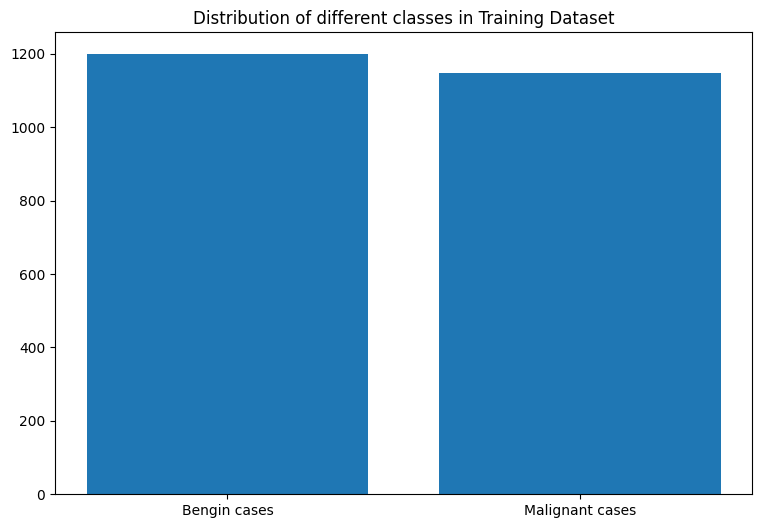

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import pathlib

image_folder = ['Bengin cases', 'Malignant cases']
nimgs = {}
for i in image_folder:
    nimages = len(os.listdir('C:\\Users\\Devar\\Desktop\\Lung Cancer Detection\\Dataset\\Split_data_vgg16_o\\train\\'+i+'\\'))
    nimgs[i]=nimages
plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Training Dataset')
plt.show()

In [12]:
for class_name, class_dir in {
    'Bengin cases': TRAINING_BENGIN_DIR,
    'Malignant cases': TRAINING_MALIGNANT_DIR
}.items():
    image_count = len(os.listdir(class_dir))
    print(f'Training {class_name} images are: {image_count}')

Training Bengin cases images are: 1199
Training Malignant cases images are: 1147


In [13]:
for i in ['Bengin cases', 'Malignant cases']:
    validation_class_dir = os.path.join(validation_dir, i)
    os.makedirs(validation_class_dir, exist_ok=True)
    print(f"Testing {i} images are: {len(os.listdir(validation_class_dir))}")

Testing Bengin cases images are: 426
Testing Malignant cases images are: 428


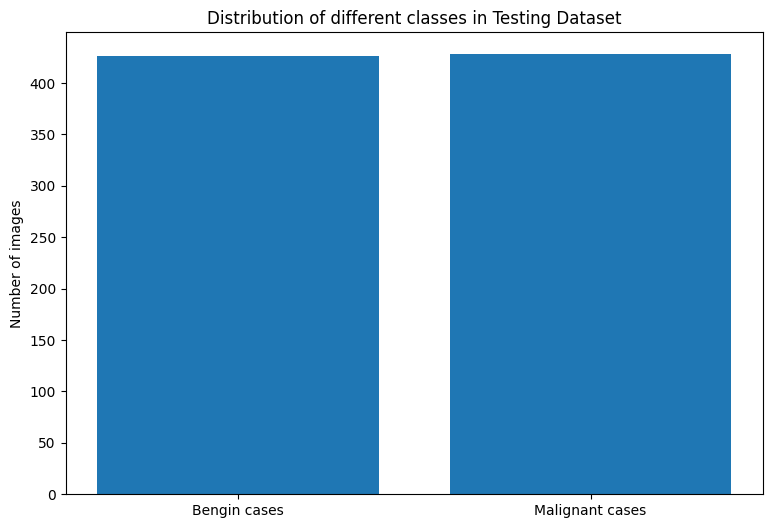

In [14]:
image_folder = ['Bengin cases', 'Malignant cases']
nimgs = {}

for class_name in image_folder:
    class_path = pathlib.Path(validation_dir) / class_name
    nimgs[class_name] = len(list(class_path.iterdir()))

plt.figure(figsize=(9, 6))
plt.bar(list(nimgs.keys()), list(nimgs.values()), align='center')
plt.title('Distribution of different classes in Testing Dataset')
plt.ylabel('Number of images')
plt.show()

In [15]:
!pip install tensorflow==2.21.0

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl (350.9 MB)
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Dropout
from keras.layers import Flatten

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [54]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=8,
                                   zoom_range=0.15,
                                   width_shift_range=0.15,
                                   height_shift_range=0.15,
                                   shear_range=0.10,
                                   horizontal_flip=True,
                                   brightness_range=[0.8,1.2],
                                   channel_shift_range=0.15,
                                   fill_mode="nearest")

In [55]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [57]:
x_train = train_datagen.flow_from_directory(
	train_dir,
	target_size=(224, 224),
	batch_size=32,
	class_mode='binary'
)

x_test = test_datagen.flow_from_directory(
	validation_dir,
	target_size=(224, 224),
	batch_size=32,
	class_mode='binary'
)

print(x_train.class_indices)
print(x_test.class_indices)

Found 1140 images belonging to 2 classes.
Found 0 images belonging to 2 classes.
{'Bengin cases': 0, 'Malignant cases': 1}
{'Bengin cases': 0, 'Malignant cases': 1}


In [ ]:
# Safety check: fail fast with a clear message instead of a deep Keras
# traceback if either generator picked up 0 images. This typically happens
# when this cell is (re)run before the train/validation folders have been
# populated by the split_data step above (e.g. cells executed out of order,
# or a stale kernel state) — rerun with Kernel > Restart & Run All if this
# fires while the folders on disk actually contain images.
if x_train.samples == 0:
    raise RuntimeError(
        f"No training images found in '{train_dir}'. "
        "Re-run the data split cells above, then Restart & Run All."
    )
if x_test.samples == 0:
    raise RuntimeError(
        f"No validation images found in '{validation_dir}'. "
        "Re-run the data split cells above, then Restart & Run All."
    )

In [60]:
print('Contents of training directory:')
print(os.listdir(train_dir))

print('\nContents of validation directory:')
print(os.listdir(validation_dir))

Contents of training directory:
['Bengin cases', 'Malignant cases']

Contents of validation directory:
['Bengin cases', 'Malignant cases']


In [61]:
from tensorflow.keras.layers import Convolution2DTranspose
from tensorflow.keras.models import Sequential

In [62]:
from tensorflow.keras.applications.vgg16 import VGG16
base_model=VGG16(input_shape=(224,224,3),include_top=False,weights='imagenet')# leave out of the last fully connected layer

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [63]:
for layer in base_model.layers:
    layer.trainable=False

In [64]:
x=layers.Flatten()(base_model.output)
x=layers.Dense(512,activation='relu')(x)

x=layers.Dropout(0.5)(x)
x=layers.Dense(1,activation='sigmoid')(x)
model=tf.keras.models.Model(base_model.input,x)
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [65]:
TRAIN_COUNT =len(x_train.filepaths)
TEST_COUNT=len(x_test.filepaths)
TRAIN_STEPS_PER_EPOCH= round(TRAIN_COUNT/32)
VAL_STEPS_PER_EPOCH = round(TEST_COUNT/32)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
EARLY_STOP_PATIENCE = 5

In [4]:
from tensorflow.python.keras.callbacks import EarlyStopping,ModelCheckpoint
EARLY_STOP_PATIENCE =5

In [17]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

if "train_dir" not in globals():
    split_data_dir = r"C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Split_data_vgg16_o"
    train_dir = os.path.join(split_data_dir, "train")

if "validation_dir" not in globals():
    validation_dir = os.path.join(split_data_dir, "validation")

if "train_datagen" not in globals():
    ImageDataGenerator = tf.keras.preprocessing.image.ImageDataGenerator

    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=8,
        zoom_range=0.15,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.10,
        horizontal_flip=True,
        brightness_range=(0.8, 1.2),
        channel_shift_range=0.15,
        fill_mode="nearest"
    )

if "test_datagen" not in globals():
    test_datagen = ImageDataGenerator(rescale=1.0 / 255)

x_train = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary'
)

x_test = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    shuffle=False
)

TRAIN_STEPS_PER_EPOCH = max(1, (x_train.samples + x_train.batch_size - 1) // x_train.batch_size)
VAL_STEPS_PER_EPOCH = max(1, (x_test.samples + x_test.batch_size - 1) // x_test.batch_size)

tf.keras.backend.clear_session()

base_model = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

for layer in base_model.layers:
    layer.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(base_model.input, x)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

EARLY_STOP_PATIENCE = 5

cb_early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)
cb_checkpointer = ModelCheckpoint(
    filepath='best_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)
callbacks = [cb_checkpointer, cb_early_stopper]

# Fix the MKL/CPU memory issue that can happen with VGG16 on Windows
try:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except RuntimeError:
    pass

# Lower the batch size to reduce memory pressure during training
x_train.batch_size = 4
x_test.batch_size = 4

TRAIN_STEPS_PER_EPOCH = max(1, (x_train.samples + x_train.batch_size - 1) // x_train.batch_size)
VAL_STEPS_PER_EPOCH = max(1, (x_test.samples + x_test.batch_size - 1) // x_test.batch_size)

history = model.fit(
    x_train,
    steps_per_epoch=TRAIN_STEPS_PER_EPOCH,
    epochs=20,
    validation_data=x_test,
    validation_steps=VAL_STEPS_PER_EPOCH,
    callbacks=callbacks
)

Found 2346 images belonging to 2 classes.
Found 854 images belonging to 2 classes.

Epoch 1/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 790s 1s/step - accuracy: 0.7408 - loss: 0.5050 - val_accuracy: 0.9098 - val_loss: 0.2766
Epoch 2/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 725s 1s/step - accuracy: 0.8713 - loss: 0.3170 - val_accuracy: 0.9415 - val_loss: 0.1992
Epoch 3/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 748s 1s/step - accuracy: 0.9007 - loss: 0.2537 - val_accuracy: 0.9403 - val_loss: 0.1663
Epoch 4/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 746s 1s/step - accuracy: 0.9096 - loss: 0.2269 - val_accuracy: 0.9590 - val_loss: 0.1325
Epoch 5/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 717s 1s/step - accuracy: 0.9292 - loss: 0.1991 - val_accuracy: 0.9555 - val_loss: 0.1348
Epoch 6/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 723s 1s/step - accuracy: 0.9373 - loss: 0.1811 - val_accuracy: 0.9578 - val_loss: 0.1238
Epoch 7/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 746s 1s/step - accuracy: 0.9322 - loss: 0.1721 - val_accuracy: 0.9660 - val_loss: 0.1026
Epoch 8/20
58

## Evaluate & save the trained model

In [5]:
# Plot training vs validation accuracy/loss curves
# If the training cell was not run yet, do not crash the notebook.
if 'history' not in globals():
    print(
        "Training history is not available. "
        "Run the model.fit(...) training cell first, then rerun this plotting cell."
    )
else:
    hist = history.history

    acc = hist.get('accuracy', hist.get('acc', []))
    val_acc = hist.get('val_accuracy', hist.get('val_acc', []))
    loss = hist.get('loss', [])
    val_loss = hist.get('val_loss', [])

    if not acc and not val_acc and not loss and not val_loss:
        print("Training history exists, but it contains no values to plot.")
    else:
        epochs_range = range(
            1,
            max(len(acc), len(val_acc), len(loss), len(val_loss), 1) + 1
        )

        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        if acc:
            plt.plot(epochs_range[:len(acc)], acc, label='Training Accuracy')
        if val_acc:
            plt.plot(epochs_range[:len(val_acc)], val_acc, label='Validation Accuracy')
        plt.legend(loc='lower right')
        plt.title('Accuracy')

        plt.subplot(1, 2, 2)
        if loss:
            plt.plot(epochs_range[:len(loss)], loss, label='Training Loss')
        if val_loss:
            plt.plot(epochs_range[:len(val_loss)], val_loss, label='Validation Loss')
        plt.legend(loc='upper right')
        plt.title('Loss')

        plt.tight_layout()
        plt.show()

Training history is not available. Run the model.fit(...) training cell first, then rerun this plotting cell.


c:\Users\Devar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 62 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\Devar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 62 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded model architecture from: C:\Users\Devar\Desktop\Lung Cancer Detection\Backend\Models\VGG16_lung_cancer.keras
Loaded weights from: C:\Users\Devar\Desktop\Lung Cancer Detection\Backend\best_weights.weights.h5
Final validation loss: 0.2148
Final validation accuracy: 0.9356

Classification report:
Bengin cases         precision=0.9245 recall=0.9484 f1-score=0.9363 support=426
Malignant cases      precision=0.9472 recall=0.9229 f1-score=0.9349 support=428

Confusion matrix:
[[404  22]
 [ 33 395]]


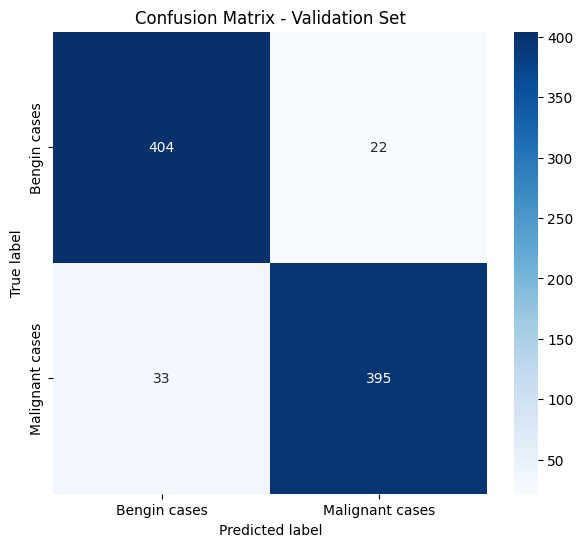

In [13]:
# Ensure required modules are available in this notebook kernel.
if 'os' not in globals():
    import os
if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'sns' not in globals():
    import seaborn as sns
if 'tf' not in globals():
    try:
        import tensorflow as tf
    except ModuleNotFoundError:
        %pip install tensorflow
        import tensorflow as tf

# Recreate validation data if the training/evaluation cell was not run in this kernel
if 'x_test' not in globals():
    if 'validation_dir' not in globals():
        split_data_dir = r"C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Split_data_vgg16_o"
        validation_dir = os.path.join(split_data_dir, "validation")

    if 'test_datagen' not in globals():
        test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255)

    x_test = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(224, 224),
        batch_size=4,
        class_mode='binary',
        shuffle=False
    )

    print(f"Recreated x_test from: {validation_dir}")
    print(f"Validation samples: {x_test.samples}")

if 'model' not in globals():
    # Try to load a previously saved model from disk.
    # Prefer full model files (.keras / .h5 with architecture) over weight-only files.
    candidate_model_paths = [
        os.path.join(os.getcwd(), "best_model.keras"),
        os.path.join(os.getcwd(), "model.keras"),
        os.path.join(os.getcwd(), "lung_cancer_model.keras"),
        os.path.join(os.getcwd(), "vgg16_model.keras"),
        os.path.join(os.getcwd(), "best_model.h5"),
        os.path.join(os.getcwd(), "model.h5"),
        os.path.join(
            r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend",
            "best_model.keras"
        ),
        os.path.join(
            r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend",
            "model.keras"
        ),
        os.path.join(
            r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend",
            "best_model.h5"
        ),
        os.path.join(
            r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend",
            "best_weights.weights.h5"
        ),
        os.path.join(
            r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend",
            "Models",
            "VGG16_lung_cancer.keras"
        ),
    ]

    model_path = next((p for p in candidate_model_paths if os.path.exists(p)), None)

    if model_path is None:
        # Search the project tree too, because the model may not be in the
        # exact folder assumed above.
        project_root = os.path.abspath(r"C:\Users\Devar\Desktop\Lung Cancer Detection")
        for root, _, files in os.walk(project_root):
            for file_name in files:
                lower_name = file_name.lower()
                if lower_name.endswith((".keras", ".h5")):
                    if "weights" not in lower_name and (
                        "model" in lower_name or "best" in lower_name or "vgg" in lower_name
                    ):
                        candidate_model_paths.append(os.path.join(root, file_name))

        # Remove duplicates while preserving order
        candidate_model_paths = list(dict.fromkeys(candidate_model_paths))

        model_path = next((p for p in candidate_model_paths if os.path.exists(p)), None)

        if model_path is None:
            raise FileNotFoundError(
                "No trained model was found on disk. "
                "Run the training cell to create a model, or set the correct model_path "
                "to your saved .keras/.h5 file.\n"
                f"Checked paths: {candidate_model_paths}"
            )

    # If the selected file is a weight-only checkpoint, load a full model architecture first.
    model_path_lower = model_path.lower()
    if "weights" in model_path_lower:
        architecture_candidates = [
            os.path.join(os.getcwd(), "best_model.keras"),
            os.path.join(os.getcwd(), "model.keras"),
            os.path.join(os.getcwd(), "lung_cancer_model.keras"),
            os.path.join(os.getcwd(), "vgg16_model.keras"),
            os.path.join(
                r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend",
                "best_model.keras"
            ),
            os.path.join(
                r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend",
                "model.keras"
            ),
            os.path.join(
                r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend",
                "Models",
                "VGG16_lung_cancer.keras"
            ),
        ]

        architecture_path = next((p for p in architecture_candidates if os.path.exists(p)), None)
        if architecture_path is None:
            raise ValueError(
                f"Found only a weights file: {model_path}. "
                "Please provide a full .keras model file or retrain/save the model properly."
            )

        model = tf.keras.models.load_model(architecture_path)
        model.load_weights(model_path)
        print(f"Loaded model architecture from: {architecture_path}")
        print(f"Loaded weights from: {model_path}")
    else:
        model = tf.keras.models.load_model(model_path)
        print(f"Loaded model from: {model_path}")

# x_test was created with shuffle=False, so predictions line up with x_test.classes in order
x_test.reset()
val_loss_final, val_acc_final = model.evaluate(
    x_test,
    steps=max(1, (x_test.samples + x_test.batch_size - 1) // x_test.batch_size),
    verbose=0
)

print(f"Final validation loss: {val_loss_final:.4f}")
print(f"Final validation accuracy: {val_acc_final:.4f}")

x_test.reset()
y_true = x_test.classes[:x_test.samples]
y_pred_probs = model.predict(
    x_test,
    steps=max(1, (x_test.samples + x_test.batch_size - 1) // x_test.batch_size),
    verbose=0
)[:x_test.samples]
y_pred = (y_pred_probs.ravel() >= 0.5).astype(int)

class_labels = list(x_test.class_indices.keys())
cm = np.zeros((len(class_labels), len(class_labels)), dtype=int)

for true_label, predicted_label in zip(y_true, y_pred):
    cm[true_label, predicted_label] += 1

print("\nClassification report:")

for label_index, label_name in enumerate(class_labels):
    true_positive = cm[label_index, label_index]
    false_positive = cm[:, label_index].sum() - true_positive
    false_negative = cm[label_index, :].sum() - true_positive

    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    f1_score = (
        2 * precision * recall / max(precision + recall, 1e-12)
    )

    print(
        f"{label_name:20s} "
        f"precision={precision:.4f} "
        f"recall={recall:.4f} "
        f"f1-score={f1_score:.4f} "
        f"support={cm[label_index, :].sum()}"
    )

print("\nConfusion matrix:")
print(cm)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - Validation Set')
plt.show()

In [ ]:
# Save the FULL model (architecture + weights), not just weights, so it can
# be loaded directly with load_model() elsewhere (e.g. by Backend/app.py).
# best_weights.weights.h5 only holds weights and needs the exact same
# architecture rebuilt in code before it can be applied.
MODELS_DIR = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Backend\Models'
os.makedirs(MODELS_DIR, exist_ok=True)

final_model_path = os.path.join(MODELS_DIR, 'VGG16_lung_cancer.keras')
model.save(final_model_path)
print(f"Saved full model to: {final_model_path}")